# Source Injector

The source injector can produce mock simulated data independent of the MEGAlib software.

Standard data simulation requires the users to install and use MEGAlib to convolve the source model with the detector effects to generate data. The source injector utilizes the response generated by intensive simulation, which contains the statistical detector effects. With the source injector, you can convolve response, source model, and orientation to gain the mock data quickly. 

The advantages of using the source injector include:

- No need to install and use MEGAlib
- Get the data much faster than the standard simulation pipeline
- The generated data are in the format that can be used for spectral fitting, localization, imaging, etc.

The disadvantages are:

- The data are binned based on the binning of the response, which means that you lost the unbinned event distribution as you will get from the MEGAlib pipeline.
- If the response is coarse, the data you generated might not be precise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import astropy.units as u
import pandas as pd
from pathlib import Path
from astropy.coordinates import SkyCoord
import astropy.units as u
from astromodels.functions.function import Function1D, FunctionMeta
from cosipy import SpacecraftFile
from source_injector_New import SourceInjector
from histpy import Histogram
from threeML import Powerlaw, Band, Gaussian
from cosipy.threeml.custom_functions import SpecFromDat
from cosipy.util import fetch_wasabi_file
import shutil
import os

%matplotlib inline

20:05:52 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=467241;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=413486;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=475707;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=433718;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


20:05:53 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=783685;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=548146;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=713076;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=286963;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=503693;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=421064;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=752953;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=705928;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=588164;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=308400;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=234976;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=991241;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
DATA_DIR = Path('/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/')

## Inject a source response

### Method 1 : Define the point source

In this method, we are setting up an analytical function (eg: a power law model) to simulate the spectral characteristics of a point source:

In [3]:
response_path = DATA_DIR / '44Ti/psr_scatt_hist.h5'
orientation_path = DATA_DIR / 'data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth.ori'

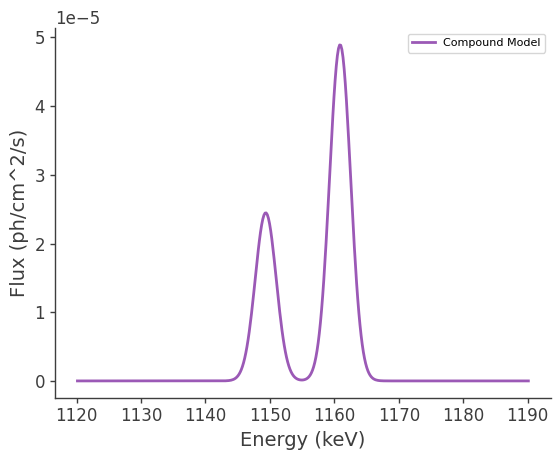

In [4]:
# Define the first Gaussian
F1 = 2e-4 / u.cm / u.cm / u.s
mu1 = 1160.89 * u.keV
sigma1 = 1.63 * u.keV

gaussian1 = Gaussian()
gaussian1.F.value = F1.value
gaussian1.F.min_value = F1.value / 1e3
gaussian1.F.max_value = F1.value * 1e3
gaussian1.F.unit = F1.unit
gaussian1.mu.value = mu1.value
gaussian1.mu.min_value = mu1.value - 10
gaussian1.mu.max_value = mu1.value + 10
gaussian1.mu.unit = mu1.unit
gaussian1.sigma.value = sigma1.value
gaussian1.sigma.min_value = sigma1.value - 1
gaussian1.sigma.max_value = sigma1.value + 5
gaussian1.sigma.unit = sigma1.unit

# Define the second Gaussian
F2 = 1e-4 / u.cm / u.cm / u.s
mu2 = 1149.35 * u.keV
sigma2 = 1.63 * u.keV

gaussian2 = Gaussian()
gaussian2.F.value = F2.value
gaussian2.F.min_value = F2.value / 1e3
gaussian2.F.max_value = F2.value * 1e3
gaussian2.F.unit = F2.unit
gaussian2.mu.value = mu2.value
gaussian2.mu.min_value = mu2.value - 10
gaussian2.mu.max_value = mu2.value + 10
gaussian2.mu.unit = mu2.unit
gaussian2.sigma.value = sigma2.value
gaussian2.sigma.min_value = sigma2.value - 1
gaussian2.sigma.max_value = sigma2.value + 5
gaussian2.sigma.unit = sigma2.unit

# Create the compound model
compound_model = gaussian1 + gaussian2

# Generate some data for plotting
x_data = np.linspace(mu1.value - 25 * sigma1.value, mu2.value + 25 * sigma2.value, 400)
y_data = compound_model(x_data)

# Plot the compound model
plt.plot(x_data, y_data, label="Compound Model")
plt.xlabel("Energy (keV)")
plt.ylabel("Flux (ph/cm^2/s)")
plt.legend()
plt.show()

In [5]:
# Gaussian.info()

### Get the expected counts and save to a data file

In [5]:
# define the target coordinates (Cas A)
source_coord = SkyCoord.from_name('Cas A').galactic

In [6]:
# Define an injector by the response
injector = SourceInjector(response_path=response_path, response_frame='galactic')  # XXX: Why does class constructor have this. Can't this be added as a parameter to the function inject_point_source()?

CPU times: user 27.3 ms, sys: 7.11 ms, total: 34.4 ms
Wall time: 33.5 ms


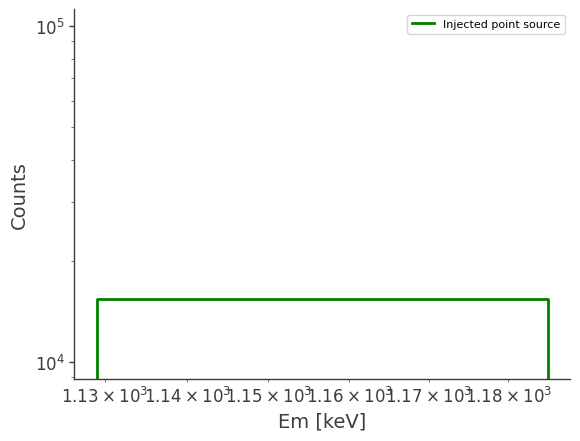

In [9]:
%%time

file_path = "sources/CasA_injected.h5"

# Get the data of the injected source
injector.inject_point_source(spectrum = compound_model, coordinate = source_coord, source_name = "Cas A",
                             make_spectrum_plot = True, data_save_path = file_path, project_axes = None)